In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense
from tensorflow.keras.layers import Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
lfw = fetch_lfw_people(
    min_faces_per_person=50,
    resize=1.0,
    color=True
)

print(lfw.images.shape)
print(lfw.target.shape)

(1560, 125, 94, 3)
(1560,)


In [ ]:
print(lfw.target_names)
print("Number of classes:", len(lfw.target_names))

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Jacques Chirac' 'Jean Chretien'
 'John Ashcroft' 'Junichiro Koizumi' 'Serena Williams' 'Tony Blair']
Number of classes: 12


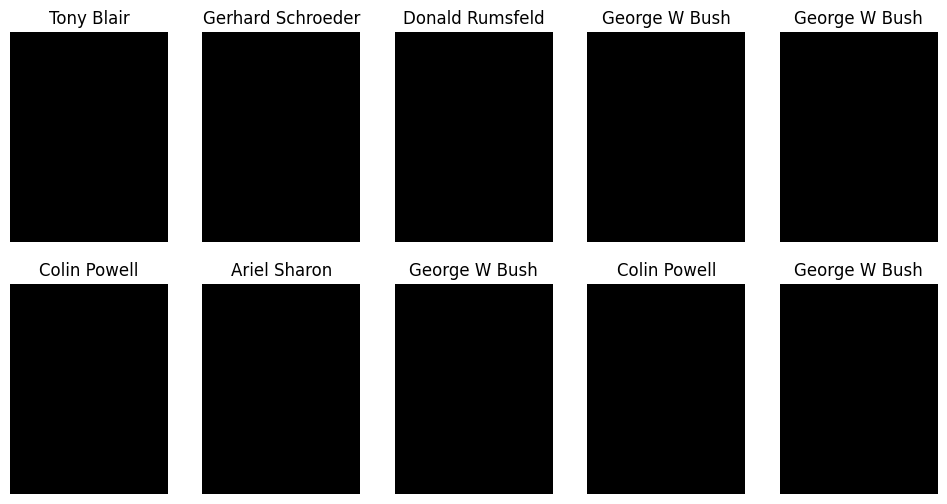

In [ ]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(lfw.images[i].astype("uint8"))
    plt.title(lfw.target_names[lfw.target[i]])
    plt.axis("off")

plt.show()

In [ ]:
print("Image shape:", lfw.images.shape)
print("Data type:", lfw.images.dtype)
print("Minimum pixel value:", lfw.images.min())
print("Maximum pixel value:", lfw.images.max())
print("Number of classes:", len(lfw.target_names))
print(lfw.target_names)

Image shape: (1560, 125, 94, 3)
Data type: float32
Minimum pixel value: 0.0
Maximum pixel value: 1.0
Number of classes: 12
['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Jacques Chirac' 'Jean Chretien'
 'John Ashcroft' 'Junichiro Koizumi' 'Serena Williams' 'Tony Blair']


In [ ]:
X = lfw.images
y = lfw.target

print("Images:", X.shape)
print("Labels:", y.shape)

Images: (1560, 125, 94, 3)
Labels: (1560,)


In [ ]:
from tensorflow.keras.utils import to_categorical

num_classes = len(lfw.target_names)

y = to_categorical(y, num_classes)

print(y.shape)

(1560, 12)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Images : (1248, 125, 94, 3)
Testing Images  : (312, 125, 94, 3)
Training Labels : (1248, 12)
Testing Labels  : (312, 12)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True
)

train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=32
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential()

# First Convolution Block
model.add(Conv2D(32, (3,3), activation='relu', padding='same',
                 input_shape=(125,94,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Second Convolution Block
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Third Convolution Block
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.30))

# Fully Connected Layer
model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.50))

# Output Layer
model.add(Dense(12, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 125, 94, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 125, 94, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 62, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 62, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 62, 47, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 31, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 31, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 31, 23, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 31, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21120)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     5,406,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,504,204 (21.00 MB)

 Trainable params: 5,503,756 (21.00 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=4,
    verbose=1
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=(X_test, y_test),
    epochs=40,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 16s 158ms/step - accuracy: 0.2204 - loss: 6.5009 - val_accuracy: 0.0353 - val_loss: 22.3688 - learning_rate: 0.0010
Epoch 2/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step - accuracy: 0.2804 - loss: 2.4119 - val_accuracy: 0.0417 - val_loss: 18.0780 - learning_rate: 0.0010
Epoch 3/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - accuracy: 0.3285 - loss: 2.3523 - val_accuracy: 0.3269 - val_loss: 10.5408 - learning_rate: 0.0010
Epoch 4/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.3397 - loss: 2.2771 - val_accuracy: 0.2051 - val_loss: 11.1195 - learning_rate: 0.0010
Epoch 5/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.3373 - loss: 2.2442 - val_accuracy: 0.3910 - val_loss: 10.0668 - learning_rate: 0.0010
Epoch 6/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.3325 - loss: 2.1375 - val_accuracy: 0.3526 - val_loss: 8.2660 - learning_rate: 0.0010
Epoch 7/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - accuracy: 0.3694 - loss: 2.0

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy * 100)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6987 - loss: 0.8511
Test Loss: 0.8511263728141785
Test Accuracy: 69.87179517745972


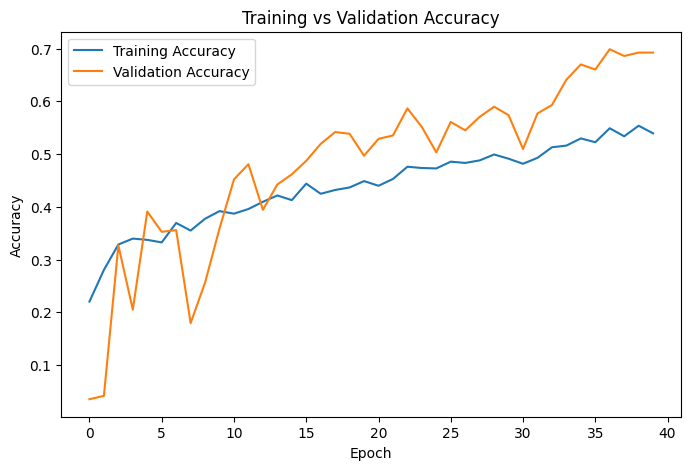

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()